## Part 1: Distributed Data Processing with Spark

In [1]:
#ALL IMPORTED LIBRARIES USED
import requests
import os 
import time

import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType
from pyspark.sql.window import Window

from langchain_community.document_loaders import PyPDFDirectoryLoader
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma

from langchain_text_splitters import RecursiveCharacterTextSplitter
from pypdf import PdfReader


C:\Users\arves\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Task 1.1: Spark Environment Setup & Data Loading

#### Creating the Spark Session Locally

In [2]:
spark = SparkSession.builder \
 .master('local[*]') \
 .appName('COMP3610_Assignment3') \
 .config('spark.sql.adaptive.enabled', 'true') \
 .config('spark.driver.memory', '4g') \
 .config('spark.sql.adaptive.coalescePartitions.enabled', 'true') \
 .getOrCreate()

# Verify the session
print(f'Spark version: {spark.version}')
print(f'App name: {spark.sparkContext.appName}')
print(f'Master: {spark.sparkContext.master}')
print(f'Default parallelism: {spark.sparkContext.defaultParallelism}')

Spark version: 3.3.2
App name: COMP3610_Assignment3
Master: local[*]
Default parallelism: 8


In [3]:
# The Spark UI is available at http://localhost:4040 while the session is active
print(f'Spark UI: http://localhost:4040')
print(f'Number of executor cores: {spark.sparkContext.defaultParallelism}')
# List available configurations
for key, value in sorted(spark.sparkContext.getConf().getAll()):
 if 'memory' in key.lower() or 'core' in key.lower() or 'master' in key.lower():
    print(f' {key} = {value}')

Spark UI: http://localhost:4040
Number of executor cores: 8
 spark.driver.memory = 4g
 spark.master = local[*]


####  Loading the NYC Yellow Taxi Parquet data into a Spark DataFrame and Pandas DataFrame

In [4]:
#Download NYC Taxi Data Locally First

#This is the directory where the files are stored
os.makedirs("data/raw", exist_ok=True)
YELLOW_TAXI_URL = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet"
DESTINATION_PATH = "data/raw/yellow_tripdata_2024-01.parquet"


print(f"Beginning download of {YELLOW_TAXI_URL}...")
try:
    #Make request to url for the parquet file
    response = requests.get(YELLOW_TAXI_URL, stream=True)
    response.raise_for_status() # Check if request was successful

    #We then open the file to download the data to
    with open(DESTINATION_PATH, 'wb') as file:
        for chunk in response.iter_content(chunk_size=8192):
            if chunk:
                file.write(chunk)

    print(f"Download completed and saved to {DESTINATION_PATH}.")
    print(f"Total file size is : {os.path.getsize(DESTINATION_PATH) / 1e6:.1f} MB")
except requests.exceptions.RequestException as e:
    print(f"An error occurred while downloading {YELLOW_TAXI_URL}: {e}")

Beginning download of https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet...
Download completed and saved to data/raw/yellow_tripdata_2024-01.parquet.
Total file size is : 50.0 MB


In [5]:
# Load the data into a Spark DataFrame and Check Load Time
pyspark_time_start = time.time()
pyspark_df = spark.read.parquet(DESTINATION_PATH)
pyspark_load_time = time.time() - pyspark_time_start

# Load the data into a Pandas DataFrame and Check Load Time
pandas_time_start = time.time()
pandas_df = pd.read_parquet(DESTINATION_PATH)
pandas_load_time = time.time() - pandas_time_start

print(f"pyspark load time: {pyspark_load_time: .2f}s")
print(f"pandas load time: {pandas_load_time : .2f}s")

pyspark load time:  4.95s
pandas load time:  0.31s


We notice substantial time increase when loading into a Pandas DataFrame compared to a Pyspark DataFrame since Pyspark leverages distributed and parallel processing across a cluster of machines whereas pandas is limited to in-memory, single-machine processing. Furthermore Pyspark is Multi-threaded while Pandas is Single-threaded

However on first load we do notice a substantial time increase of 3-4 seconds due to the cold start up overheads and lazy evaluation setup

#### Reporting Details of Dataset using Pyspark DataFrame

In [6]:
pyspark_df.printSchema()

root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp (nullable = true)
 |-- tpep_dropoff_datetime: timestamp (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)



In [7]:
print(f"The number of rows in the dataset are : {pyspark_df.count()}")
print(f'Partition count : {pyspark_df.rdd.getNumPartitions()} \n\n')

print("The dataset is as follows:")
pyspark_df.show(5, truncate=True)


The number of rows in the dataset are : 2964624
Partition count : 8 


The dataset is as follows:
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|       2| 2023-12-31 20:57:55|  2023-12-31 21:17:43|              1|         1.72|      

### Task 1.2: Data Cleaning & Feature Engineering in Spark

#### Removing rows with null values in: pickup/dropoff times, locations, fare, distance

In [8]:
CRITICAL_COLS = [
    'tpep_pickup_datetime', 'tpep_dropoff_datetime',
    'PULocationID', 'DOLocationID', 'fare_amount', 'trip_distance',
]

rows_before_null_filter = pyspark_df.count()
cleaned_pyspark_df = pyspark_df.dropna(subset=CRITICAL_COLS)

print(f"The initial rows before null filtering were:        {rows_before_null_filter}")
print(f"The rows after the null filter in the dataset is:   {cleaned_pyspark_df.count()}")
print(f"Total rows removed were:                            {rows_before_null_filter-pyspark_df.count()}")

The initial rows before null filtering were:        2964624
The rows after the null filter in the dataset is:   2964624
Total rows removed were:                            0


#### Filtering out invalid trips: zero/negative distance, negative fares, fares exceeding $500, dropoff before pickup

In [9]:
rows_before_invalid_filter = pyspark_df.count()
pyspark_df = pyspark_df.filter(
    (F.col('trip_distance') > 0) &
    (F.col('fare_amount') >= 0) &
    (F.col('fare_amount') <= 500) &
    (F.col('tpep_dropoff_datetime') > F.col('tpep_pickup_datetime')) 
)

print(f"The initial rows before filtering out invalid columns were:         {rows_before_invalid_filter}")
print(f"The rows after filtering out invalid columns in the dataset is:     {pyspark_df.count()}")
print(f"Total rows removed were:                                            {rows_before_invalid_filter-pyspark_df.count()}")

The initial rows before filtering out invalid columns were:         2964624
The rows after filtering out invalid columns in the dataset is:     2870046
Total rows removed were:                                            94578


#### Creating derived columns for better data analysis

In [10]:
#Adding trip_duration_minutes column
pyspark_df = pyspark_df.withColumn(
    'trip_duration_minutes',
    ((F.unix_timestamp('tpep_dropoff_datetime') -
    F.unix_timestamp('tpep_pickup_datetime')) / 60)
    .cast(DoubleType())
)

#Adding trip_speed_mph column
pyspark_df = pyspark_df.withColumn(
    'trip_speed_mph',
    (F.when(F.col('trip_duration_minutes')/60 > 0,
           F.col('trip_distance') / (F.col('trip_duration_minutes') / 60.0))
    .otherwise(None))
    .cast(DoubleType())
)

#Adding pickup_hour column
pyspark_df = pyspark_df.withColumn(
    'pickup_hour',
    F.hour('tpep_pickup_datetime')
)

#Adding pickup_day_of_week column
pyspark_df = pyspark_df.withColumn(
    'pickup_day_of_week',
    F.dayofweek('tpep_pickup_datetime')
)

#Adding tip_percentage column
pyspark_df = pyspark_df.withColumn(
    'tip_percentage',
    (F.when((F.col('fare_amount') >0),
           F.col('tip_amount')/F.col('fare_amount') * 100))
    .otherwise(None)
    .cast(DoubleType())
)

### Task 1.3 — Spark SQL Analytics

#### Query 1: What are the top 10 busiest pickup hours, and what is the average fare and tip percentage for each?

In [11]:
# Register as a temporary view
pyspark_df.createOrReplaceTempView('taxi_trips')

In [12]:
spark.sql("""
    SELECT
        ROW_NUMBER() OVER (ORDER BY trip_count DESC) AS rank,
        pickup_hour,
        trip_count,
        avg_fare,
        avg_tip_pct
    FROM (
        SELECT
            pickup_hour,
            COUNT(*) AS trip_count,
            ROUND(AVG(fare_amount), 2) AS avg_fare,
            ROUND(AVG(tip_percentage), 2) AS avg_tip_pct
        FROM taxi_trips
        GROUP BY pickup_hour
    )
    ORDER BY rank
    LIMIT 10
""").show()

+----+-----------+----------+--------+-----------+
|rank|pickup_hour|trip_count|avg_fare|avg_tip_pct|
+----+-----------+----------+--------+-----------+
|   1|         14|    206281|   17.01|      22.78|
|   2|         13|    200310|   18.12|      22.34|
|   3|         12|    184968|   19.46|      21.84|
|   4|         11|    184004|   19.11|       19.8|
|   5|         15|    178810|   17.63|      22.86|
|   6|         10|    178026|   19.27|       19.8|
|   7|          9|    165355|   18.42|      19.79|
|   8|          8|    159912|    17.8|      19.74|
|   9|         17|    155910|   18.29|      21.88|
|  10|         16|    155559|   18.05|      22.17|
+----+-----------+----------+--------+-----------+



We notice that the busiest pickup hours are in the afternoon from 12-2pm, this may be due to people leaving work or going out for leisure activities. Without the day of the week to compare it can be generalized that most people use the taxi service after work hours to go home or in the morning from 8-10am to arrive to work.

#### Query 2: Which day of the week has the highest average trip speed? Include average distance and duration

In [13]:
spark.sql(""" 
    SELECT 
          pickup_day_of_week,
          CASE pickup_day_of_week
            WHEN 1 THEN 'Sunday'    WHEN 2 THEN 'Monday'
            WHEN 3 THEN 'Tuesday'   WHEN 4 THEN 'Wednesday'
            WHEN 5 THEN 'Thursday'  WHEN 6 THEN 'Friday'
            WHEN 7 THEN 'Saturday'
          END  AS day_name,
          ROUND(AVG(trip_speed_mph), 2) AS avg_trip_speed,
          ROUND(AVG(trip_distance), 2) AS avg_trip_distance,
          ROUND(AVG(trip_duration_minutes), 2) AS avg_trip_duration
    FROM taxi_trips
    WHERE trip_speed_mph IS NOT NULL
    GROUP BY pickup_day_of_week
    ORDER BY avg_trip_speed DESC
""").show()

+------------------+---------+--------------+-----------------+-----------------+
|pickup_day_of_week| day_name|avg_trip_speed|avg_trip_distance|avg_trip_duration|
+------------------+---------+--------------+-----------------+-----------------+
|                 3|  Tuesday|         17.44|             4.24|            16.16|
|                 1|   Sunday|         16.15|             4.07|             14.7|
|                 2|   Monday|         13.98|             3.83|             15.8|
|                 7| Saturday|         13.34|             3.38|            14.91|
|                 6|   Friday|         13.18|             3.58|            15.72|
|                 5| Thursday|         12.58|             3.53|            16.37|
|                 4|Wednesday|         12.36|             3.59|            16.23|
+------------------+---------+--------------+-----------------+-----------------+



We notice that Tuesday shows the highest trip speed along with Sunday, this may be due to reduced traffic congestion on these days so the taxi's can move faster with the trip distance and duration also being longer due to this.

#### Query 3: Using a window function, rank the top 5 pickup locations by total revenue for each day of the week.

In [14]:
spark.sql("""
        WITH revenue_by_loc AS(
          SELECT
                pickup_day_of_week,
                PULocationID as pickup_location,
                ROUND(SUM(total_amount),2) as total_revenue
          FROM taxi_trips
          GROUP BY pickup_day_of_week, PULocationID
        ),
        ranked AS(
          SELECT *,
                RANK() OVER(
                        PARTITION BY pickup_day_of_week
                        ORDER BY total_revenue DESC
                ) AS revenue_rank
          FROM revenue_by_loc
        )
        SELECT * FROM ranked
        WHERE revenue_rank <=5
        ORDER BY revenue_rank, pickup_day_of_week     
""").show(35, truncate=False)

+------------------+---------------+-------------+------------+
|pickup_day_of_week|pickup_location|total_revenue|revenue_rank|
+------------------+---------------+-------------+------------+
|1                 |132            |1611212.28   |1           |
|2                 |132            |2068017.7    |1           |
|3                 |132            |1786490.1    |1           |
|4                 |132            |1635524.25   |1           |
|5                 |132            |1417026.64   |1           |
|6                 |132            |1384194.47   |1           |
|7                 |132            |1283109.29   |1           |
|1                 |138            |789210.77    |2           |
|2                 |138            |1015948.07   |2           |
|3                 |138            |946888.41    |2           |
|4                 |138            |991222.8     |2           |
|5                 |138            |844295.29    |2           |
|6                 |138            |7629

Without the zone table it is hard to know exactly where these locations are however it can be safe to assume that the areas which generate the highest revenue are airports and city centers where commuters travel into the city or around it to get to work, home or for leisure activities. It should also be noted that weekdays generate the most amount of money which may be from commuters going to and from work

#### Query 4: Calculate the cumulative trip count by hour of day (running total from hour 0 to 23). At what hour does the cumulative count surpass 50% of daily trips?

In [15]:
query4 = spark.sql("""
        WITH hourly AS (
            SELECT pickup_hour, COUNT(*) AS hourly_trips
            FROM taxi_trips
            GROUP BY pickup_hour
        ),
        cumulative AS(
            SELECT pickup_hour, hourly_trips,
            SUM(hourly_trips) OVER (
                ORDER BY pickup_hour
                ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
            ) AS cumulative_trips
            FROM hourly
        ),
        total AS (SELECT SUM(hourly_trips) AS total_trips FROM hourly )
        SELECT pickup_hour, hourly_trips, cumulative_trips,
               ROUND(cumulative_trips/total_trips * 100,2) as cumulative_trips_perc
        FROM cumulative CROSS JOIN total
        ORDER BY pickup_hour
           
""")

query4.show(24)
crossover_hour = query4.filter(query4.cumulative_trips_perc >= 50).first().pickup_hour
print(f"The hour at which the cumulative count surpasses 50% of daily trips is hour {crossover_hour}")

+-----------+------------+----------------+---------------------+
|pickup_hour|hourly_trips|cumulative_trips|cumulative_trips_perc|
+-----------+------------+----------------+---------------------+
|          0|       15284|           15284|                 0.53|
|          1|       17495|           32779|                 1.14|
|          2|       39415|           72194|                 2.52|
|          3|       80870|          153064|                 5.33|
|          4|      113506|          266570|                 9.29|
|          5|      125619|          392189|                13.66|
|          6|      135425|          527614|                18.38|
|          7|      146754|          674368|                 23.5|
|          8|      159912|          834280|                29.07|
|          9|      165355|          999635|                34.83|
|         10|      178026|         1177661|                41.03|
|         11|      184004|         1361665|                47.44|
|         

The cumulative count for trips surpasses 50% of the total daily trips at around midday 12pm indicating that half of the trips in the day are for commuters going to work and the other half are for them going from from work in the afternoon with the taxi service

#### Query 5: Compare average fare, distance, and tip percentage between short trips (<2miles), medium trips (2–10 miles), and long trips (>10 miles). Which category has the highest tip percentage?


In [16]:
query5 = spark.sql("""
        SELECT
            CASE
                WHEN trip_distance < 2 THEN 'Short trip (< 2  miles)'
                WHEN trip_distance <= 10 THEN 'Medium trip (2-10 miles)'
                ELSE 'Long trip (> 10 miles)'
            END AS distance_category,
            ROUND(AVG(fare_amount), 2) AS avg_fare,
            ROUND(AVG(trip_distance), 2) AS avg_trip_distance,
            ROUND(AVG(tip_percentage), 2) AS avg_tip_pct
        FROM taxi_trips
        GROUP BY distance_category
""")

query5.show()

max_tip_perc = query5.orderBy(F.desc('avg_tip_pct')).first()

print(f"The trip category with the highest tip percentage is {max_tip_perc.distance_category} with a tip percentage of {max_tip_perc.avg_tip_pct}%")

+--------------------+--------+-----------------+-----------+
|   distance_category|avg_fare|avg_trip_distance|avg_tip_pct|
+--------------------+--------+-----------------+-----------+
|Medium trip (2-10...|   22.18|             3.96|      18.57|
|Short trip (< 2  ...|    9.91|             1.13|      23.07|
|Long trip (> 10 m...|   64.65|             21.7|      21.93|
+--------------------+--------+-----------------+-----------+

The trip category with the highest tip percentage is Short trip (< 2  miles) with a tip percentage of 23.07%


We observe that for longer trips the average fare is siginicantly greater but shor trips still bring in the higher tip percentages as customers are more pleased with a shorter trip than one that is longer, however medium trips received the lowest tip percentage with customers being more likely to tip for shorter trips or ones which are long.

### Task 1.4: Performance Optimization 

#### We first run benchmarks to check the query performance on cached vs uncached dataframe

In [17]:
#We use the query below for benchmarking
BENCHMARK_QUERY = """
    WITH hourly AS (
            SELECT pickup_hour, COUNT(*) AS hourly_trips
            FROM taxi_trips
            GROUP BY pickup_hour
        ),
        cumulative AS(
            SELECT pickup_hour, hourly_trips,
            SUM(hourly_trips) OVER (
                ORDER BY pickup_hour
                ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
            ) AS cumulative_trips
            FROM hourly
        ),
        total AS (SELECT SUM(hourly_trips) AS total_trips FROM hourly )
        SELECT pickup_hour, hourly_trips, cumulative_trips,
               ROUND(cumulative_trips/total_trips * 100,2) as cumulative_trips_perc
        FROM cumulative CROSS JOIN total
        ORDER BY pickup_hour
"""

#We use the 4th query created earlier

In [18]:
#Helper Benchmarking function to measure performance
def benchmark(name, runs=5):
    times = []
    for _ in range(runs):
        start = time.time()
        spark.sql(BENCHMARK_QUERY).collect()
        times.append(time.time()-start)
    avg_time = sum(times) / len(times)
    print(f'{name}: {avg_time:.3f}s (avg of {runs} runs)')
    return avg_time

In [19]:
print("----BENCHMARKS FOR UNCACHED VS CACHED----\n")

#Run benchmark on uncached DataFrame and record performance
uncached_time =benchmark("Uncached DataFrame")

#Cache the DataFrame then retrieve
pyspark_df.cache()

#Run benchmark on cached DataFrame on materialize and record performance
cahed_time_unmaterialized = benchmark("Cached DataFrame(Unmaterialized)", runs=1)

#Run benchmark on cached DataFrame after materialize and record performance
cached_time_materialized =benchmark("Cached DataFrame(Materialized)")

print(f"Speedup from caching after materializing the cached is: {uncached_time - cached_time_materialized}s")

----BENCHMARKS FOR UNCACHED VS CACHED----

Uncached DataFrame: 0.763s (avg of 5 runs)
Cached DataFrame(Unmaterialized): 7.635s (avg of 1 runs)
Cached DataFrame(Materialized): 0.324s (avg of 5 runs)
Speedup from caching after materializing the cached is: 0.43914356231689455s


In [20]:
spark.sparkContext._jvm.org.apache.hadoop.util.VersionInfo.getVersion()

# spark.sparkContext._jvm.org.apache.hadoop.util.Shell.getHadoopHome()

# spark.sparkContext._jvm.org.apache.hadoop.fs.FileSystem.getLocal(
#     spark.sparkContext._jsc.hadoopConfiguration()
# )

'3.3.2'

#### Storing Parquet File in Partitioned Format By pickup_hour

In [21]:
OUTPUT_PATH = "data/cleaned/"

pyspark_df.write.mode('overwrite').partitionBy('pickup_hour').parquet(OUTPUT_PATH)
print('DataFrame partitioned by pickup hour and stored')

for item in sorted(os.listdir(OUTPUT_PATH)):
    if item.startswith('pickup_hour'):
        files = os.listdir(os.path.join(OUTPUT_PATH, item))
        parquet_files = [f for f in files if f.endswith('.parquet')]
        print(f'{item}: {len(parquet_files)} file(s)')


DataFrame partitioned by pickup hour and stored
pickup_hour=0: 3 file(s)
pickup_hour=1: 3 file(s)
pickup_hour=10: 3 file(s)
pickup_hour=11: 3 file(s)
pickup_hour=12: 3 file(s)
pickup_hour=13: 3 file(s)
pickup_hour=14: 3 file(s)
pickup_hour=15: 3 file(s)
pickup_hour=16: 3 file(s)
pickup_hour=17: 3 file(s)
pickup_hour=18: 3 file(s)
pickup_hour=19: 3 file(s)
pickup_hour=2: 3 file(s)
pickup_hour=20: 3 file(s)
pickup_hour=21: 3 file(s)
pickup_hour=22: 3 file(s)
pickup_hour=23: 3 file(s)
pickup_hour=3: 3 file(s)
pickup_hour=4: 3 file(s)
pickup_hour=5: 3 file(s)
pickup_hour=6: 3 file(s)
pickup_hour=7: 3 file(s)
pickup_hour=8: 3 file(s)
pickup_hour=9: 3 file(s)


In [36]:
#Now we read back a partition and confirm that less rows are retrieved
df_hour17 = spark.read.parquet(OUTPUT_PATH).filter(F.col('pickup_hour') == 17)
print(f'Rows in hour 17 partition are: {df_hour17.count():,}')
print(f'Rows in the total dataset for Janauary are: {pyspark_df.count()}')
print(f'The percentage of the data scanned out of the total dataset for hour 17 is: {df_hour17.count()/pyspark_df.count() * 100:.2f}%')
print('Partition pruning confirmed: only pickup_hour=17 directory was scanned.')

Rows in hour 17 partition are: 155,910
Rows in the total dataset for Janauary are: 2870046
The percentage of the data scanned out of the total dataset for hour 17 is: 5.43%
Partition pruning confirmed: only pickup_hour=17 directory was scanned.


#### Getting Execution Plan of Benchmark Query(Query 4)

In [39]:
spark.sql(BENCHMARK_QUERY).explain(mode='formatted')

== Physical Plan ==
AdaptiveSparkPlan (25)
+- Project (24)
   +- BroadcastNestedLoopJoin Cross BuildRight (23)
      :- Window (13)
      :  +- Sort (12)
      :     +- Exchange (11)
      :        +- HashAggregate (10)
      :           +- Exchange (9)
      :              +- HashAggregate (8)
      :                 +- InMemoryTableScan (1)
      :                       +- InMemoryRelation (2)
      :                             +- * Project (7)
      :                                +- * Project (6)
      :                                   +- * Filter (5)
      :                                      +- * ColumnarToRow (4)
      :                                         +- Scan parquet  (3)
      +- BroadcastExchange (22)
         +- HashAggregate (21)
            +- Exchange (20)
               +- HashAggregate (19)
                  +- HashAggregate (18)
                     +- Exchange (17)
                        +- HashAggregate (16)
                           +- InMemoryTableS

We used our query for finding the cumulative trip count throughout the hour of the day, firstly the data is loaded into memory(InMemoryTableScan ) and cached(InMemoryRelation ) with the parquet file first being scanned, converted into spark rows filters the rows on the WHERE clauses, selects the rows and then gets the derived columns for hourly.

Next we partition the rows on pickup hour through HashAggregate and Exchange and then shuffles all data into a single partition to sort it in ascending order

After this the window function is executed to get the cumulative total on each partition.

To get the total the query depends on what was created first(hourly), Spark must redo the group by with 3 pairs of HashAggregations nad Exchanges.

Finally the total trips is broadcasted into every executor, joined on cumulative total, computes the final column expressions and drops any intermediate tables and then dynamically coalesces shuffle partitions.

Here we see Filter(5) which executes our WHERE claus in the dataframe, this did not come from the query but from when we previously cleaned the data on trip distance and fare amount.

Scan Parquet(3) is what reads in the parquet file for the taxi trip data for it to be converted into spark rows with only necessary columns being readed.

## Part 2: RAG Pipeline over Transportation Documents

### Task 2.1: Document Collection & Ingestion

In [19]:
#Loading the documents into an object

print("Beginning loading of documents from docs folder...\n")

p = Path("docs")
total_docs = sum(1 for entry in p.iterdir() if entry.is_file())

try:
    loader = PyPDFDirectoryLoader("docs/")
    raw_documents = loader.load()
except Exception as e:
    print(f"Error loading the files from the docs/ folder: {e}")

total_characters = [len(d.page_content) for d in raw_documents]
issues = []

for doc in raw_documents:
    if len(doc.page_content.strip()) < 50:
        issues.append(f"Short/empty: page: {doc.metadata['page']}, document: {doc.metadata['source']}, Page Content: {doc.page_content}")

print(f"Loaded {total_docs} documents from the docs/ directory")
print(f"Loaded {len(raw_documents)} pages from all PDFs")
print(f"Loaded {sum(total_characters)} characters from all PDFs\n")
print(f"There were a total of {len(issues)} found in the documents:")
for issue in issues:
    print(f'  ⚠ {issue}')


Beginning loading of documents from docs folder...

Loaded 7 documents from the docs/ directory
Loaded 172 pages from all PDFs
Loaded 350234 characters from all PDFs

There were a total of 8 found in the documents:
  ⚠ Short/empty: page: 16, document: docs\2020-tlc-factbook.pdf, Page Content: 
  ⚠ Short/empty: page: 1, document: docs\mobility-report-singlepage-2019.pdf, Page Content: 2 32
  ⚠ Short/empty: page: 3, document: docs\mobility-report-singlepage-2019.pdf, Page Content: 4 5
4
  ⚠ Short/empty: page: 5, document: docs\mobility-report-singlepage-2019.pdf, Page Content: 6 7
  ⚠ Short/empty: page: 35, document: docs\mobility-report-singlepage-2019.pdf, Page Content: 36
  ⚠ Short/empty: page: 46, document: docs\mobility-report-singlepage-2019.pdf, Page Content: 46 47
Manhattan CBD & Midtown Travel Speeds
  ⚠ Short/empty: page: 48, document: docs\mobility-report-singlepage-2019.pdf, Page Content: 48 4949
49
  ⚠ Short/empty: page: 49, document: docs\mobility-report-singlepage-2019.pdf

### Task 2.2: Chunking & Embedding 

#### Splitting the document in chunks of size 1000 with an overlap of 200

In [20]:
text_splitter = RecursiveCharacterTextSplitter(
 chunk_size=1000, 
 chunk_overlap=200, 
 separators=["\n\n", "\n", ". ", " ", ""]
)

valid_pages = [p for p in raw_documents if len(p.page_content.strip()) > 50]
chunks = text_splitter.split_documents(valid_pages)
print(f"Split {len(raw_documents)} pages into {len(chunks)} chunks")

Split 172 pages into 492 chunks


#### Visualizing the chunks created

In [21]:
chunk_sizes = [len(c.page_content) for c in chunks]
print(f'Avg chunk size     : {sum(chunk_sizes)/len(chunks):.0f} chars')
print(f'Min size / Max size          : {min(chunk_sizes)} / {max(chunk_sizes)}')

print("Looking at the first 3 chunks: \n")

for i, chunk in enumerate(chunks[:3]):
    print(f"\n=== Chunk {i} ===")
    print(f"Length: {len(chunk.page_content)} chars")
    print(f"Source: {chunk.metadata}")
    print(f"Preview: {chunk.page_content[:200]}...")


Avg chunk size     : 818 chars
Min size / Max size          : 75 / 1000
Looking at the first 3 chunks: 


=== Chunk 0 ===
Length: 78 chars
Source: {'producer': 'Adobe PDF Library 15.0', 'creator': 'Adobe InDesign 15.0 (Windows)', 'creationdate': '2021-03-19T16:10:13-04:00', 'moddate': '2021-03-19T16:10:42-04:00', 'trapped': '/False', 'source': 'docs\\2020-tlc-factbook.pdf', 'total_pages': 17, 'page': 0, 'page_label': '1'}
Preview: W
2020
Bill de Blasio | Mayor
Aloysee Heredia Jarmoszuk | Commissioner & Chair...

=== Chunk 1 ===
Length: 993 chars
Source: {'producer': 'Adobe PDF Library 15.0', 'creator': 'Adobe InDesign 15.0 (Windows)', 'creationdate': '2021-03-19T16:10:13-04:00', 'moddate': '2021-03-19T16:10:42-04:00', 'trapped': '/False', 'source': 'docs\\2020-tlc-factbook.pdf', 'total_pages': 17, 'page': 1, 'page_label': '2'}
Preview: 2
TLC FACTBOOK
20202020
NN
ew York City’s for-hire industry has undergone significant 
change in the two years since the Taxi & Limousine 
Commission (T

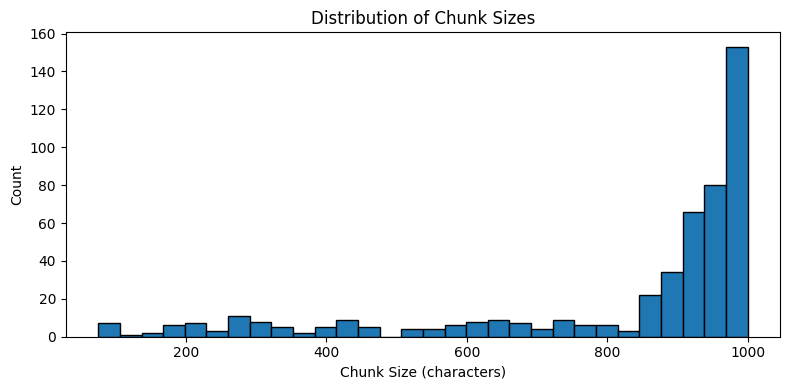

In [22]:
#Histogram of the chunks
plt.figure(figsize=(8, 4))
plt.hist(chunk_sizes, bins=30, edgecolor='black')
plt.xlabel('Chunk Size (characters)')
plt.ylabel('Count')
plt.title('Distribution of Chunk Sizes')
plt.tight_layout()
plt.show()

#### Generating embeddings using sentence-transformer and stroing in ChromaDB

In [26]:
#This removes the existing vector store to avoid duplication
import shutil
shutil.rmtree("./chroma_db", ignore_errors=True)

CHROMA_DIR = 'chroma_db'

embedding_model = HuggingFaceEmbeddings(
    model_name="all-MiniLM-L6-v2"
)

vectorstore_1000 = Chroma.from_documents(
    documents=chunks,
    embedding=embedding_model,
    persist_directory="./chroma_db",
    collection_name="assignment3_doc"
)

print(f'Stored {vectorstore_1000._collection.count()} chunks in ChromaDB at {CHROMA_DIR}/')

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1165.45it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Stored 1658 chunks in ChromaDB at chroma_db/


#### Experimenting with chunk size 200, 2000 and 1000 on 3 sample queries

In [27]:
#Our initial configs for the experiment
#We set up the text splitter with configs for chunk size 200 with varying overlaps

splitter_200  = RecursiveCharacterTextSplitter(chunk_size=200,  chunk_overlap=20)
splitter_2000 = RecursiveCharacterTextSplitter(chunk_size=2000, chunk_overlap=200)

chunks_200  = splitter_200.split_documents(valid_pages)
chunks_2000 = splitter_2000.split_documents(valid_pages)

print(f'Chunks at size  200 : {len(chunks_200):,}')
print(f'Chunks at size 1000 : {len(chunks):,}')
print(f'Chunks at size 2000 : {len(chunks_2000):,}')

# Build temporary vectorstores for the other chunks created
vectorstore_200  = Chroma.from_documents(chunks_200,  embedding_model, collection_name='experiment_200')
vectorstore_2000 = Chroma.from_documents(chunks_2000, embedding_model, collection_name='experiment_2000')

SAMPLE_QUERIES = [
    "What are the current trends in the yellow taxi service?",
    "How has yellow taxi ridership changed over recent years?",
    "Has the yellow taxi service been performing well?",
]

Chunks at size  200 : 2,233
Chunks at size 1000 : 492
Chunks at size 2000 : 265


In [28]:
#Conducting the experiment

print('\n=== Chunk Size Experiment: Top-3 Retrieved Chunks ===\n')

for query in SAMPLE_QUERIES:
    print(f'Results for Query: "{query}" \n')
    for label, vs in [("200", vectorstore_200), ("1000", vectorstore_1000), ("2000", vectorstore_2000)]:
        print(f"Chunk size:{label} ")
        results = vs.similarity_search(query, k=3)
        for i, doc in enumerate(results):
            print(f"\n--- Result {i+1} (source: {doc.metadata.get('source', 'unknown')}) ---")
            print(doc.page_content[:400])
        print("\n\n")
    print('\n' + '─' * 70 + '\n')



=== Chunk Size Experiment: Top-3 Retrieved Chunks ===

Results for Query: "What are the current trends in the yellow taxi service?" 

Chunk size:200 

--- Result 1 (source: docs\electrification_in_motion_report_2024.pdf) ---
the industry, including the city’s yellow taxicabs.
However, a more holistic view on the role of TLC-regulated industries in reducing the

--- Result 2 (source: docs\2020-tlc-factbook.pdf) ---
trips. Passengers utilized Yellow taxis far more
for pickups than drop-offs at airports. 
Highest Average Monthly Pick-Ups by 
Neighborhood 2018-2019

--- Result 3 (source: docs\2020-tlc-factbook.pdf) ---
trips. Passengers utilized Yellow taxis far more
for pickups than drop-offs at airports. 
Highest Average Monthly Pick-Ups by 
Neighborhood 2018-2019



Chunk size:1000 

--- Result 1 (source: docs\2020-tlc-factbook.pdf) ---
11
Trip Accessibility and Safety
Accessibility
In 2018 the TLC required all FHV bases 
to provide accessible service. As a 
result, licensed WAVs in th

Chunk size 200 produces small fragments that are suitable for the document provided where information is condensed into smaller text chunks with information this chunk being the most suitable where each chunk has the right amount of context.

Chunk size 1000 adds on additional context that is not needed which dilutes the amount of information present in the reports providing information that is irrelevant to the question.

Chunk Size=2000 can retrieve highly relevant passages but also bundles unrelated topics into the same chunk as information is diluted and the main context of the question is lost.

Chunk size=200 with overlap=20 consistently returned the most relevant top-3 results as it has the right amount of information per chunk without too much information diluting it but still has the revelvant details needed for the question.

### Task 2.3: RAG Pipeline Implementation

In [29]:
from langchain.prompts import PromptTemplate
from langchain.schema.runnable import RunnablePassthrough
from langchain.schema.output_parser import StrOutputParser
from langchain_anthropic import ChatAnthropic

# Load the persisted vectorstore (if continuing from a fresh kernel)
vectorstore = Chroma(
    persist_directory=CHROMA_DIR,
    embedding_function=embeddings,
    collection_name='nyc_transport_docs',
)

# Retriever: fetch top 5 most similar chunks
retriever = vectorstore.as_retriever(
    search_type='similarity',
    search_kwargs={'k': 5},
)

# LLM — swap model/base_url for your course LM server if needed
llm = ChatAnthropic(model='claude-sonnet-4-20250514', temperature=0)

# Prompt template
RAG_TEMPLATE = """You are an expert analyst on NYC transportation policy.
Answer the question using ONLY the context provided below.
If the context does not contain enough information, say so explicitly.
Always cite the source document and page number(s) that support your answer,
using the format [source_filename, p.X].

CONTEXT:
{context}

QUESTION:
{question}

ANSWER:"""

rag_prompt = PromptTemplate.from_template(RAG_TEMPLATE)


def format_docs(docs):
    """Concatenate retrieved docs into a single context string with source labels."""
    sections = []
    for doc in docs:
        src  = doc.metadata.get('source', 'unknown')
        page = doc.metadata.get('page', '?')
        sections.append(f'[{src}, p.{page}]\n{doc.page_content}')
    return '\n\n'.join(sections)


# Build the LCEL chain: retrieve → format → prompt → llm → parse
rag_chain = (
    {'context': retriever | format_docs, 'question': RunnablePassthrough()}
    | rag_prompt
    | llm
    | StrOutputParser()
)


def rag_query(question: str, k: int = 5) -> dict:
    """Run the full RAG pipeline and return answer + retrieved source docs."""
    retrieved_docs = retriever.invoke(question)
    answer         = rag_chain.invoke(question)
    return {
        'question': question,
        'answer':   answer,
        'docs':     retrieved_docs,
    }


def display_rag_result(result: dict):
    """Pretty-print a RAG result."""
    print(f"QUESTION:\n  {result['question']}\n")
    print(f"ANSWER:\n  {result['answer']}\n")
    print("SOURCES RETRIEVED:")
    for i, doc in enumerate(result['docs']):
        src  = doc.metadata.get('source', 'unknown')
        page = doc.metadata.get('page', '?')
        print(f"  [{i+1}] {src}  —  page {page}")
    print("\nCONTEXT CHUNKS:")
    for i, doc in enumerate(result['docs']):
        preview = doc.page_content[:300].replace('\n', ' ')
        print(f"\n  [Chunk {i+1}] {preview}…")
    print('\n' + '=' * 70 + '\n')

ModuleNotFoundError: No module named 'langchain.prompts'